# Решения упражнений 9.1–9.5



In [1]:
import os
import urllib.request


def download_if_missing(url, filename):
    # Download a file only if it is absent in the current directory.
    if not os.path.exists(filename):
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
    else:
        print(f"{filename} already exists")


download_if_missing(
    "https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py",
    "thinkdsp.py",
)

download_if_missing(
    "https://github.com/AllenDowney/ThinkDSP/raw/master/code/FB_2.csv",
    "FB_2.csv",
)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "complex"):
    np.complex = complex

from thinkdsp import (
    Wave,
    TriangleSignal,
    SquareSignal,
    SawtoothSignal,
    CubicSignal,
    decorate,
    zero_pad,
)

PI2 = 2 * np.pi


---

# Упражнение 9.1

**Задание.** В разделе «Нарастающая сумма» показано, что часть примеров хорошо работает для периодических сигналов. Нужно заменить периодический пилообразный сигнал на апериодические данные Facebook и посмотреть, что пойдёт не так.




Количество отсчётов: 1976
Первое значение: 38.23
Последнее значение: 163.339996
Скачок при периодическом склеивании конец→начало: -125.10999600000002


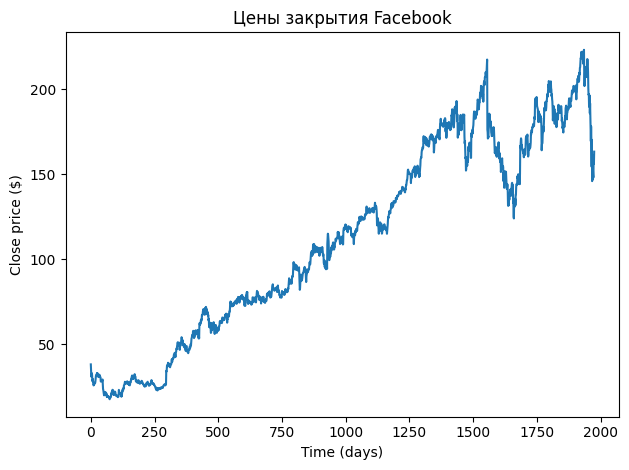

In [4]:
# Загружаем цены закрытия Facebook.
df = pd.read_csv("FB_2.csv", header=0, parse_dates=[0])
ys = df["Close"].to_numpy()

# Для FFT удобнее чётное число отсчётов.
if len(ys) % 2:
    ys = ys[:-1]

close = Wave(ys, framerate=1)
print("Количество отсчётов:", len(close))
print("Первое значение:", close.ys[0])
print("Последнее значение:", close.ys[-1])
print("Скачок при периодическом склеивании конец→начало:", close.ys[0] - close.ys[-1])

close.plot()
decorate(xlabel="Time (days)", ylabel="Close price ($)", title="Цены закрытия Facebook")

Сначала повторим схему из раздела про `cumsum`, но вместо периодического пилообразного сигнала возьмём цены Facebook. Чтобы постоянная составляющая не доминировала в нарастающей сумме, вычтем среднее значение. Это не убирает апериодичность: начало и конец всё равно не совпадают.


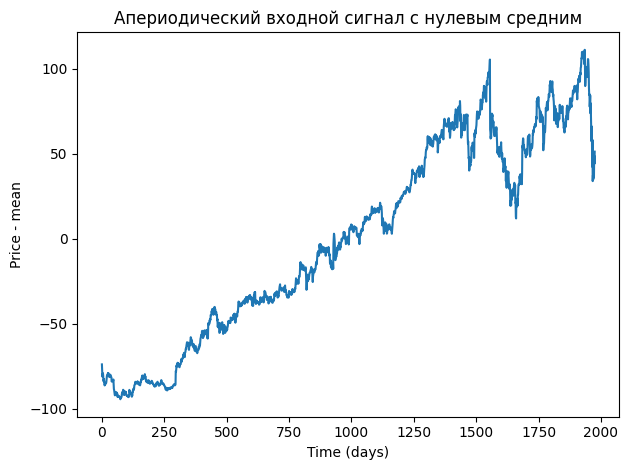

In [5]:
# Делаем нулевое среднее, чтобы убрать тривиальный огромный линейный тренд от DC-компоненты.
in_wave = close.copy()
in_wave.unbias()

in_wave.plot()
decorate(xlabel="Time (days)", ylabel="Price - mean", title="Апериодический входной сигнал с нулевым средним")

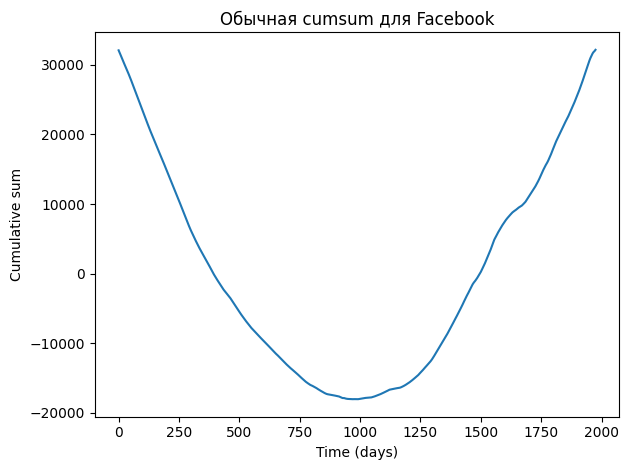

In [6]:
# Нарастающая сумма во временной области.
out_wave = in_wave.cumsum()
out_wave.unbias()

out_wave.plot()
decorate(xlabel="Time (days)", ylabel="Cumulative sum", title="Обычная cumsum для Facebook")

Максимальная абсолютная разность: 1.659827830735594e-10


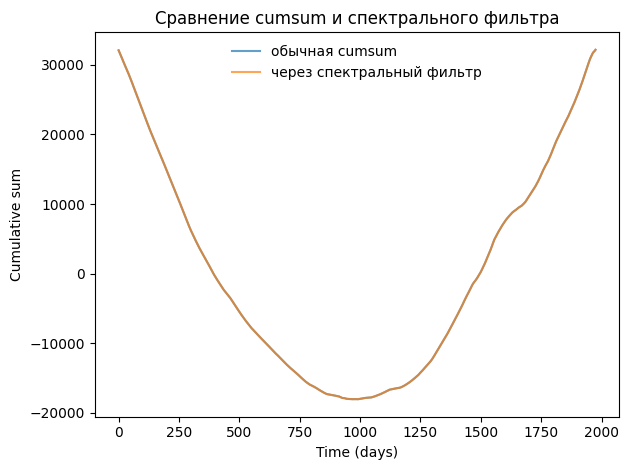

In [7]:
# Пробуем получить тот же результат через спектральный фильтр cumsum.
in_spectrum = in_wave.make_spectrum()
out_spectrum = out_wave.make_spectrum()

# Фильтр diff для окна [1, -1], затем обратный фильтр для cumsum.
diff_window = np.array([1.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()

cumsum_filter = diff_filter.copy()
cumsum_filter.hs[1:] = 1 / cumsum_filter.hs[1:]
cumsum_filter.hs[0] = 0  # DC-компонента неинвертируема; задаём её равной нулю.

# Спектральная версия cumsum.
out_wave2 = (in_spectrum * cumsum_filter).make_wave()
out_wave2.unbias()

out_wave.plot(label="обычная cumsum", alpha=0.7)
out_wave2.plot(label="через спектральный фильтр", alpha=0.7)
decorate(xlabel="Time (days)", ylabel="Cumulative sum", title="Сравнение cumsum и спектрального фильтра")

print("Максимальная абсолютная разность:", out_wave.max_diff(out_wave2))

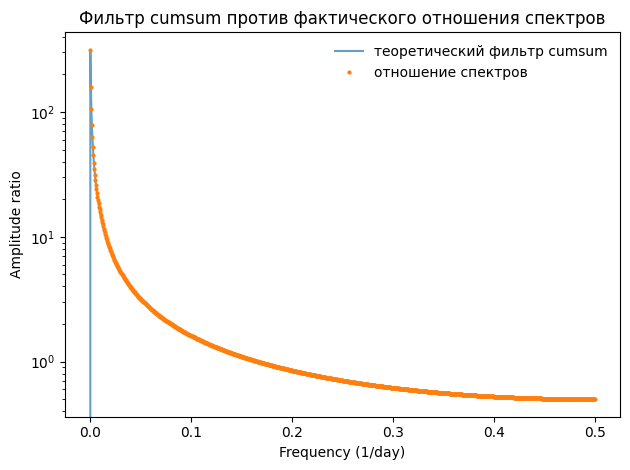

In [8]:
# Посмотрим, совпадает ли фактическое отношение спектров с теоретическим фильтром cumsum.
ratio_spectrum = out_spectrum.ratio(in_spectrum, thresh=1)

cumsum_filter.plot(label="теоретический фильтр cumsum", alpha=0.7)
ratio_spectrum.plot(label="отношение спектров", marker=".", ms=4, ls="")
decorate(
    xlabel="Frequency (1/day)",
    ylabel="Amplitude ratio",
    yscale="log",
    title="Фильтр cumsum против фактического отношения спектров",
)

**Вывод по 9.1.** Для периодического сигнала обычная нарастающая сумма и спектральный фильтр согласуются гораздо лучше. Для Facebook результат расходится, потому что:




---

# Упражнение 9.2

**Задание.** Создать треугольный сигнал, применить `diff`, затем вычислить спектр, применить `differentiate`, преобразовать обратно во временную область и сравнить результаты.


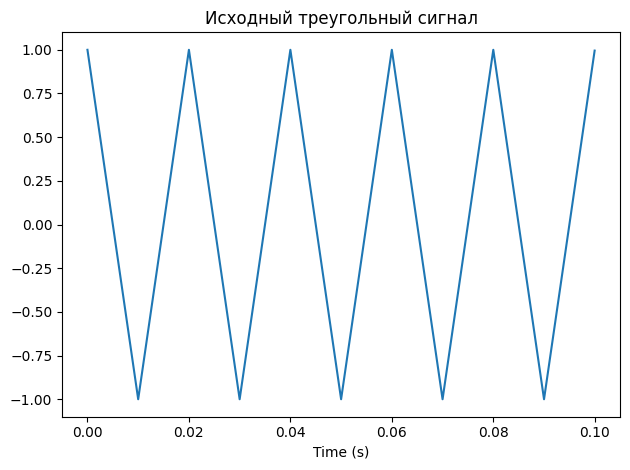

In [9]:
tri_wave = TriangleSignal(freq=50).make_wave(duration=0.1, framerate=44100)

tri_wave.plot()
decorate(xlabel="Time (s)", title="Исходный треугольный сигнал")

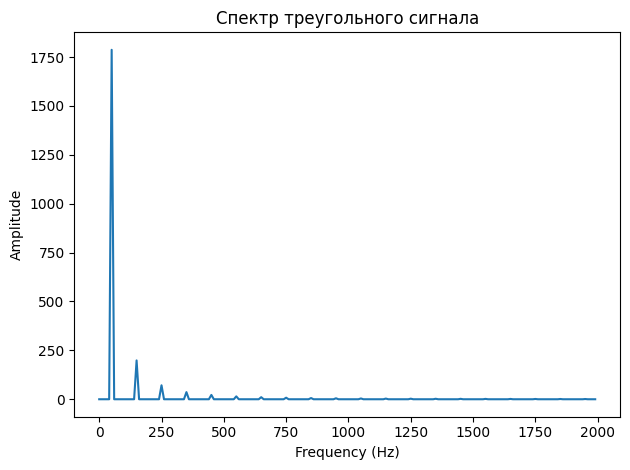

In [10]:
tri_spectrum = tri_wave.make_spectrum()
tri_spectrum.plot(high=2000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр треугольного сигнала")

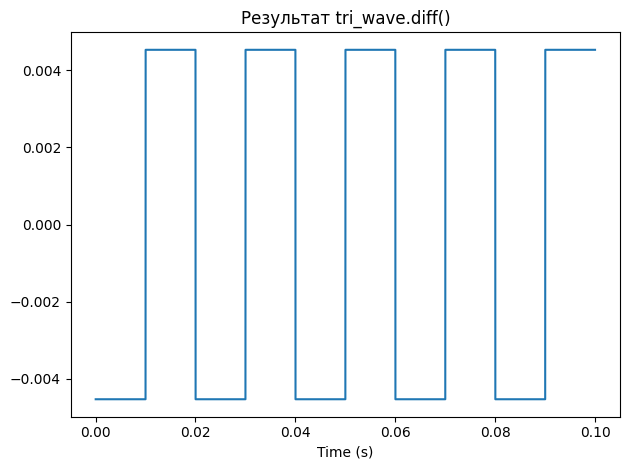

In [11]:
# Конечная разность треугольного сигнала.
diff_wave = tri_wave.diff()

diff_wave.plot()
decorate(xlabel="Time (s)", title="Результат tri_wave.diff()")

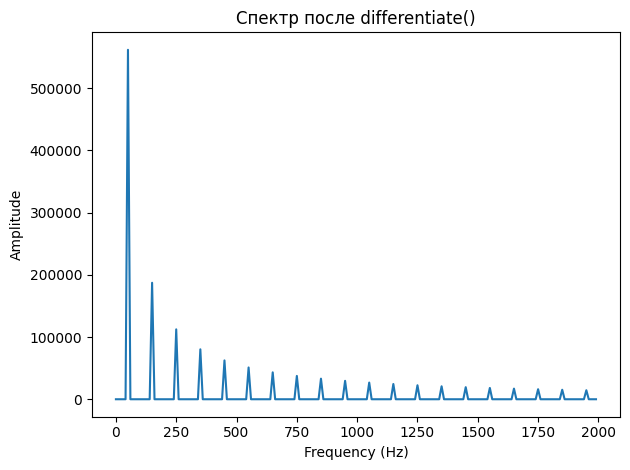

In [12]:
# Спектральное дифференцирование.
deriv_spectrum = tri_wave.make_spectrum().differentiate()

deriv_spectrum.plot(high=2000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр после differentiate()")

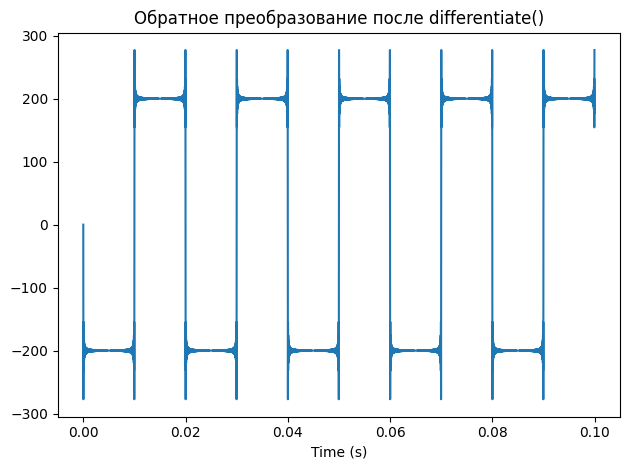

In [13]:
deriv_wave = deriv_spectrum.make_wave()

deriv_wave.plot()
decorate(xlabel="Time (s)", title="Обратное преобразование после differentiate()")

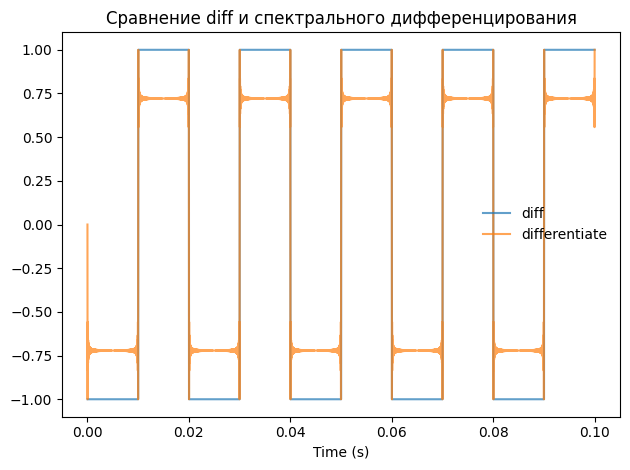

In [14]:
# Для визуального сравнения нормализуем амплитуды.
diff_compare = diff_wave.copy()
deriv_compare = deriv_wave.copy()
diff_compare.normalize()
deriv_compare.normalize()

diff_compare.plot(label="diff", alpha=0.7)
deriv_compare.plot(label="differentiate", alpha=0.7)
decorate(xlabel="Time (s)", title="Сравнение diff и спектрального дифференцирования")

**Вывод по 9.2.** `diff` превращает треугольный сигнал почти в прямоугольный, потому что производная линейных участков постоянна. `differentiate` даёт похожий прямоугольный сигнал, но около углов появляются колебания/ringing. Причина в том, что у треугольного сигнала производная в вершинах математически не определена, а спектральное дифференцирование резко усиливает высокочастотные компоненты.


---

# Упражнение 9.3

**Задание.** Создать прямоугольный сигнал, применить `cumsum`, затем вычислить спектр, применить `integrate`, преобразовать обратно во временную область и сравнить результаты.


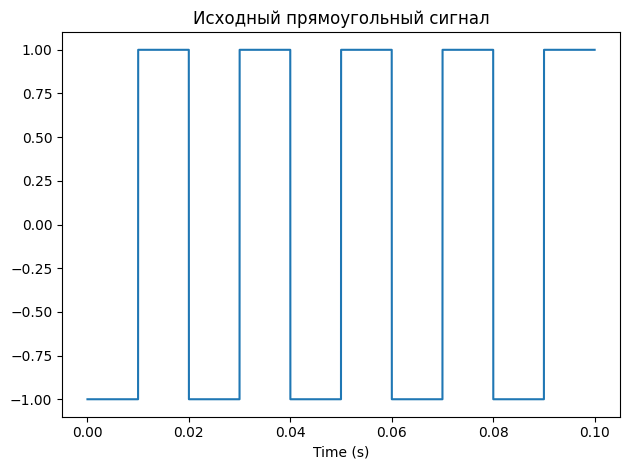

In [15]:
square_wave = SquareSignal(freq=50).make_wave(duration=0.1, framerate=44100)

square_wave.plot()
decorate(xlabel="Time (s)", title="Исходный прямоугольный сигнал")

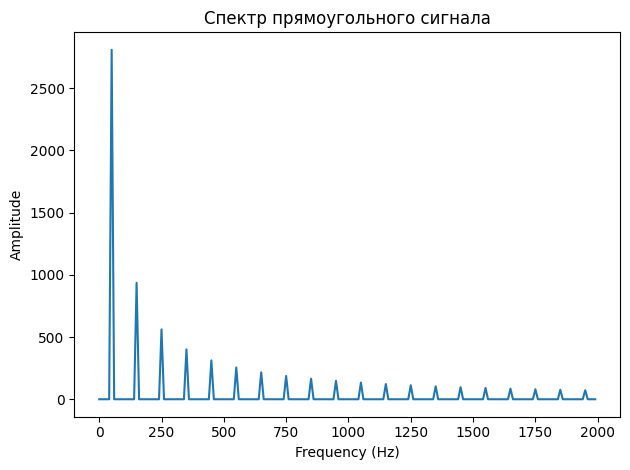

In [16]:
square_spectrum = square_wave.make_spectrum()
square_spectrum.plot(high=2000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр прямоугольного сигнала")

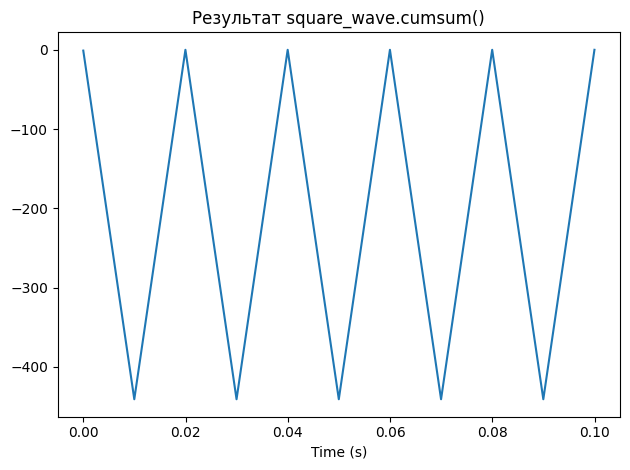

In [17]:
# Нарастающая сумма прямоугольного сигнала.
cumsum_wave = square_wave.cumsum()

cumsum_wave.plot()
decorate(xlabel="Time (s)", title="Результат square_wave.cumsum()")

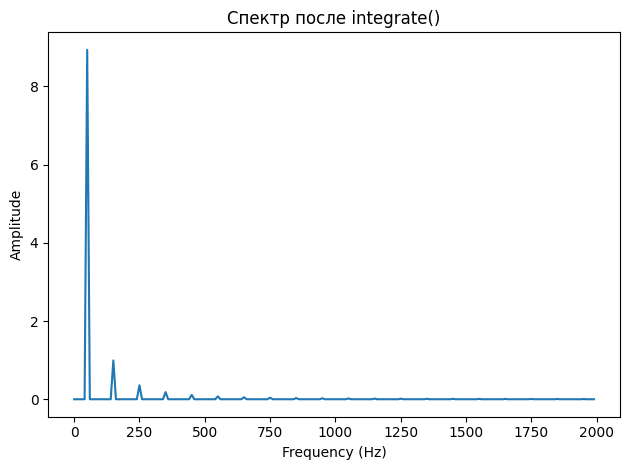

In [19]:
# Спектральное интегрирование.
integ_spectrum = square_wave.make_spectrum().integrate()
integ_spectrum.hs[0] = 0  # постоянная интегрирования не восстанавливается

integ_spectrum.plot(high=2000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр после integrate()")


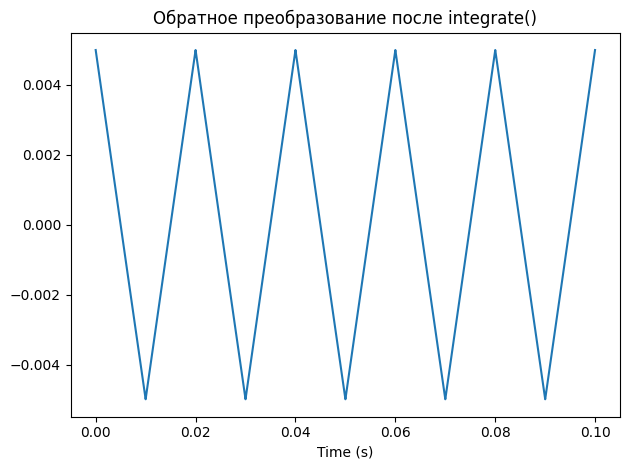

In [20]:
integ_wave = integ_spectrum.make_wave()

integ_wave.plot()
decorate(xlabel="Time (s)", title="Обратное преобразование после integrate()")


Максимальная абсолютная разность после нормировки: 0.0045351473922902175


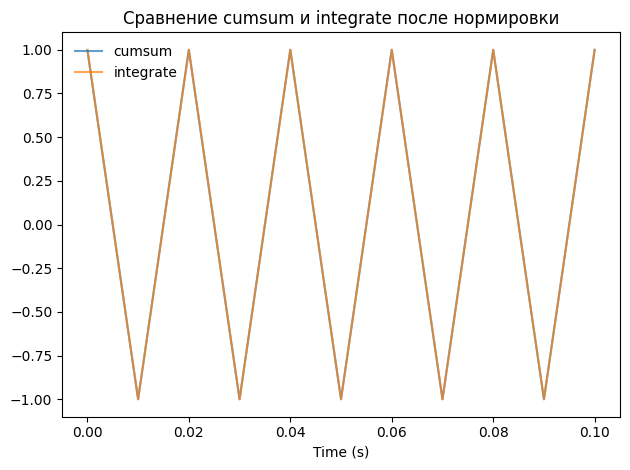

In [21]:
# После удаления смещения и нормировки формы должны быть почти одинаковыми.
cumsum_compare = cumsum_wave.copy()
integ_compare = integ_wave.copy()

cumsum_compare.unbias()
cumsum_compare.normalize()
integ_compare.unbias()
integ_compare.normalize()

cumsum_compare.plot(label="cumsum", alpha=0.7)
integ_compare.plot(label="integrate", alpha=0.7)
decorate(xlabel="Time (s)", title="Сравнение cumsum и integrate после нормировки")

print("Максимальная абсолютная разность после нормировки:", cumsum_compare.max_diff(integ_compare))


**Вывод по 9.3.** `cumsum` прямоугольного сигнала даёт треугольный сигнал. Спектральное `integrate` тоже даёт треугольную форму, но амплитуда и постоянная составляющая могут отличаться. После удаления смещения и нормировки результаты визуально почти совпадают. Различия связаны с дискретной аппроксимацией, обработкой DC-компоненты и периодическими предположениями спектрального метода.


---

# Упражнение 9.4

**Задание.** Создать пилообразный сигнал, вычислить его спектр, дважды применить `integrate`, затем напечатать/построить результирующий сигнал и его спектр. Определить математическую форму сигнала и объяснить, почему он напоминает синусоиду.


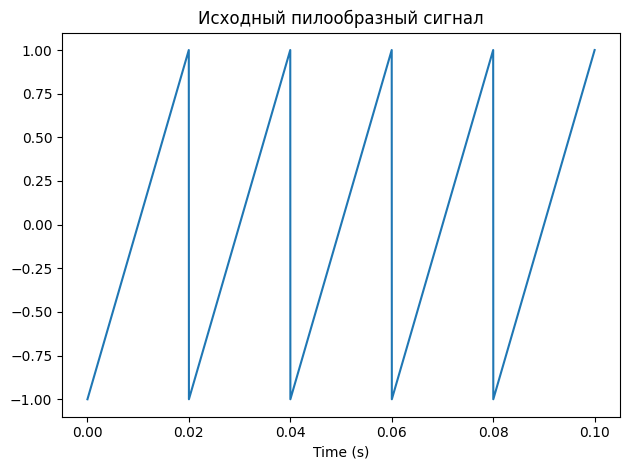

In [22]:
saw_wave = SawtoothSignal(freq=50).make_wave(duration=0.1, framerate=44100)
saw_wave.unbias()

saw_wave.plot()
decorate(xlabel="Time (s)", title="Исходный пилообразный сигнал")

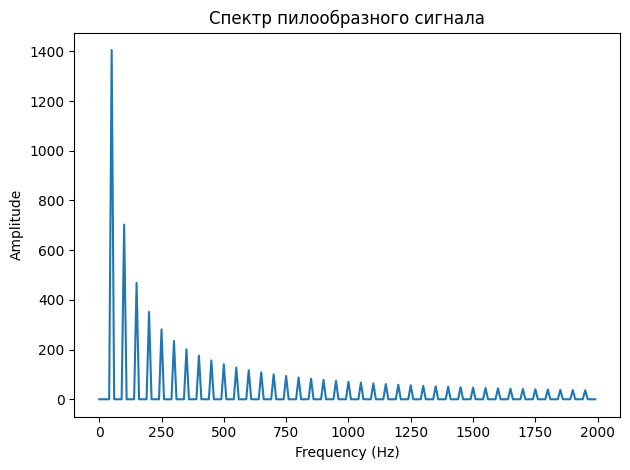

In [23]:
saw_spectrum = saw_wave.make_spectrum()
saw_spectrum.plot(high=2000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр пилообразного сигнала")

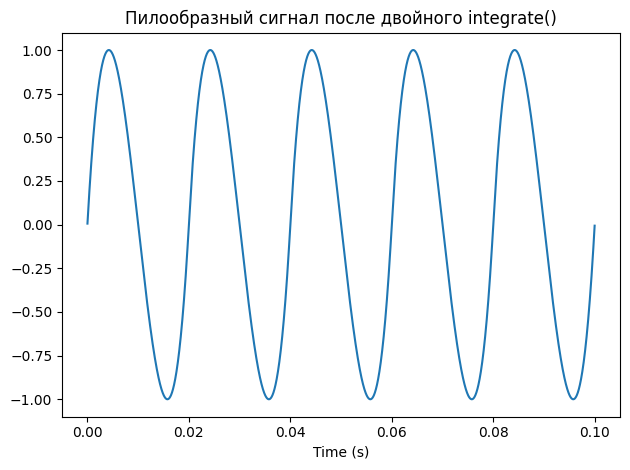

In [24]:
# Двойное спектральное интегрирование.
double_integ_spectrum = saw_wave.make_spectrum().integrate().integrate()
double_integ_spectrum.hs[0] = 0

double_integ_wave = double_integ_spectrum.make_wave()
double_integ_wave.unbias()
double_integ_wave.normalize()

double_integ_wave.plot()
decorate(xlabel="Time (s)", title="Пилообразный сигнал после двойного integrate()")

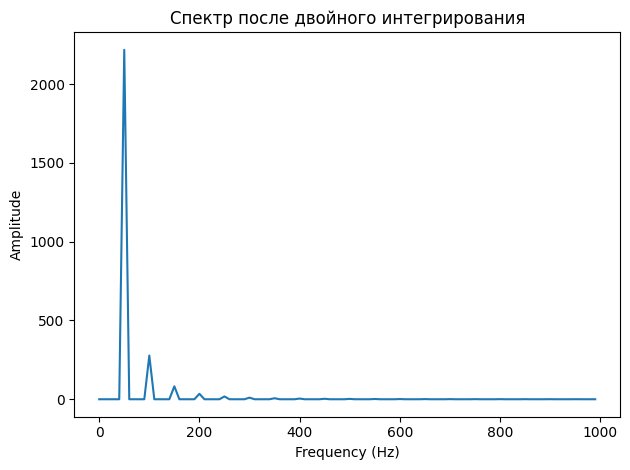

In [25]:
double_integ_spectrum2 = double_integ_wave.make_spectrum()
double_integ_spectrum2.plot(high=1000)
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude", title="Спектр после двойного интегрирования")

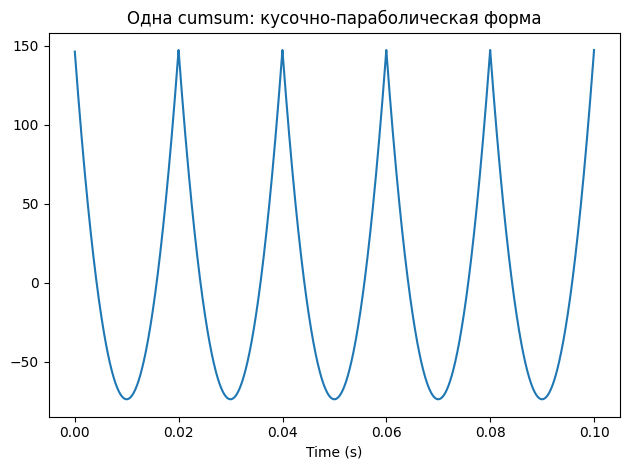

In [26]:
# Для сравнения: обычная cumsum один раз и дважды.
one_cumsum = saw_wave.cumsum()
one_cumsum.unbias()

two_cumsum = one_cumsum.cumsum()
two_cumsum.unbias()
two_cumsum.normalize()

one_cumsum.plot()
decorate(xlabel="Time (s)", title="Одна cumsum: кусочно-параболическая форма")

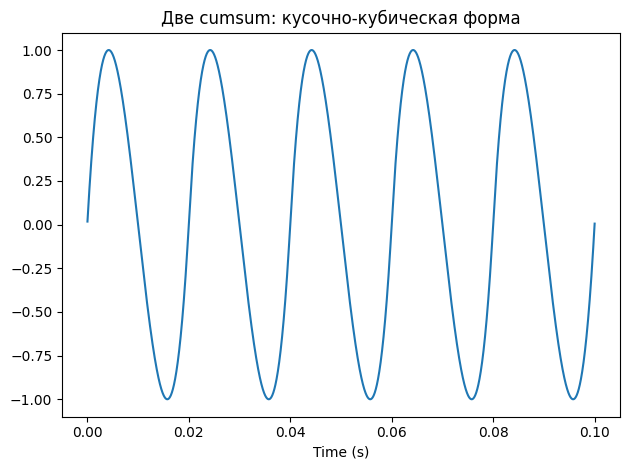

In [27]:
two_cumsum.plot()
decorate(xlabel="Time (s)", title="Две cumsum: кусочно-кубическая форма")

**Вывод по 9.4.** Интеграл пилообразного сигнала имеет кусочно-квадратичную форму, а двойной интеграл — кусочно-кубическую форму. Но результат после двойного интегрирования выглядит почти как синусоида, потому что интегрирование является фильтром нижних частот: после одного интегрирования амплитуды гармоник делятся примерно на $f$, после двух — примерно на $f^2$. Высшие гармоники сильно подавляются, и остаётся в основном фундаментальная частота.


---

# Упражнение 9.5

**Задание.** Исследовать вторую разность и вторую производную. Создать `CubicSignal`, дважды применить `diff`, затем дважды применить `differentiate`. После этого построить фильтры для второй разности и второй производной в одном масштабе, используя частоту кадров 1.


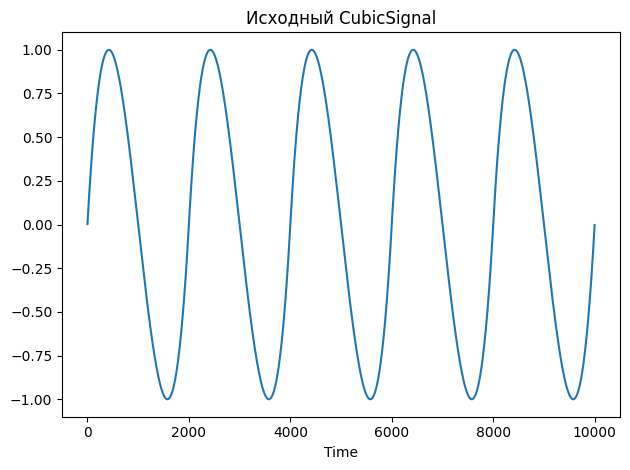

In [28]:
cubic_wave = CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)

cubic_wave.plot()
decorate(xlabel="Time", title="Исходный CubicSignal")

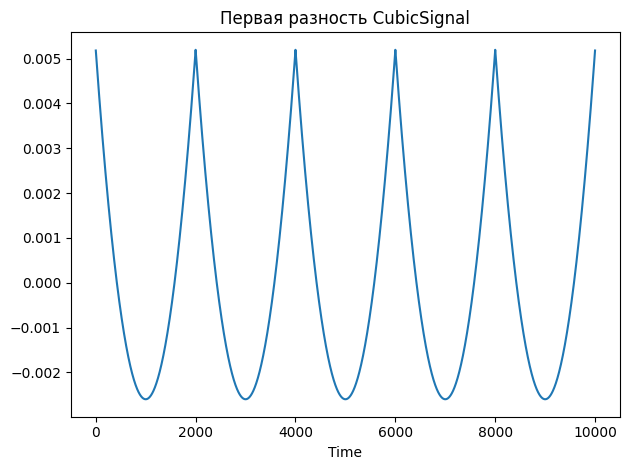

In [29]:
first_diff = cubic_wave.diff()
first_diff.plot()
decorate(xlabel="Time", title="Первая разность CubicSignal")

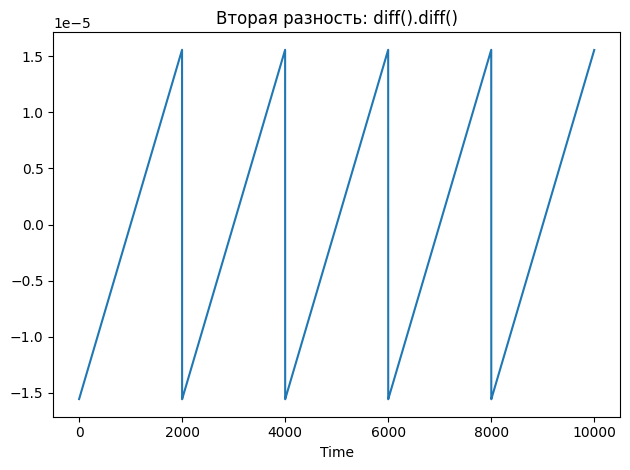

In [30]:
second_diff = first_diff.diff()
second_diff.plot()
decorate(xlabel="Time", title="Вторая разность: diff().diff()")

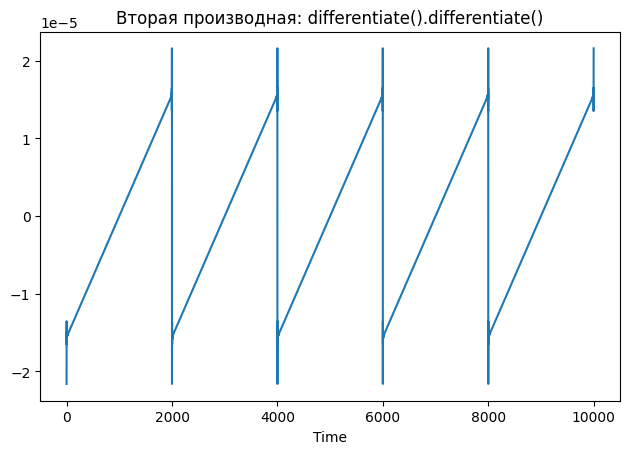

In [31]:
second_deriv_spectrum = cubic_wave.make_spectrum().differentiate().differentiate()
second_deriv_wave = second_deriv_spectrum.make_wave()

second_deriv_wave.plot()
decorate(xlabel="Time", title="Вторая производная: differentiate().differentiate()")

Теперь построим фильтры. Для второй разности используем окно `[-1, 2, -1]`. Для второй спектральной производной фильтр равен $(2\pi i f)^2$.


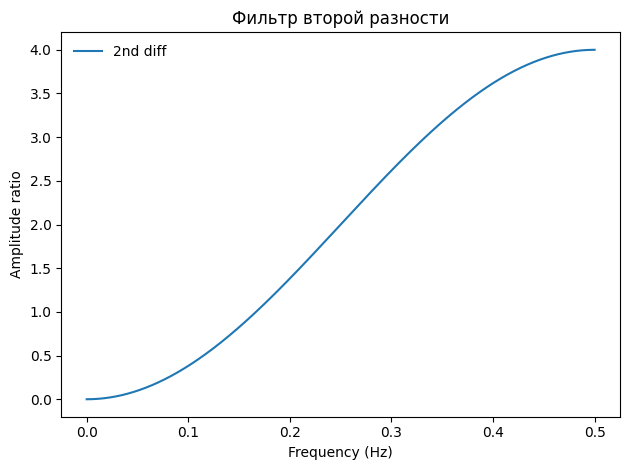

In [32]:
# Фильтр второй разности.
diff2_window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(diff2_window, len(cubic_wave))
diff2_wave = Wave(padded, framerate=cubic_wave.framerate)
diff2_filter = diff2_wave.make_spectrum()

diff2_filter.plot(label="2nd diff")
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude ratio", title="Фильтр второй разности")

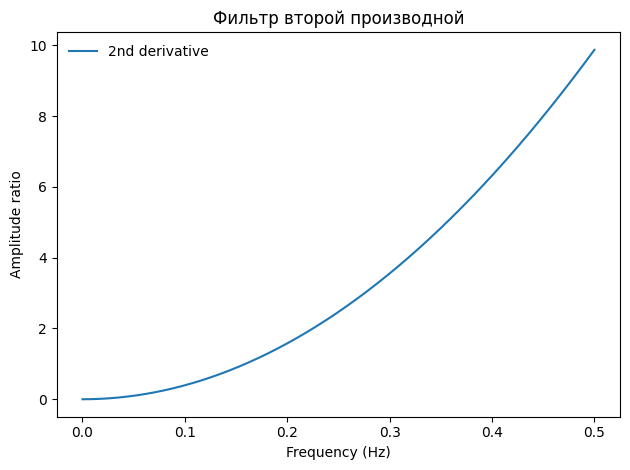

In [33]:
# Фильтр второй производной.
deriv2_filter = cubic_wave.make_spectrum()
deriv2_filter.hs = (PI2 * 1j * deriv2_filter.fs) ** 2

deriv2_filter.plot(label="2nd derivative")
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude ratio", title="Фильтр второй производной")

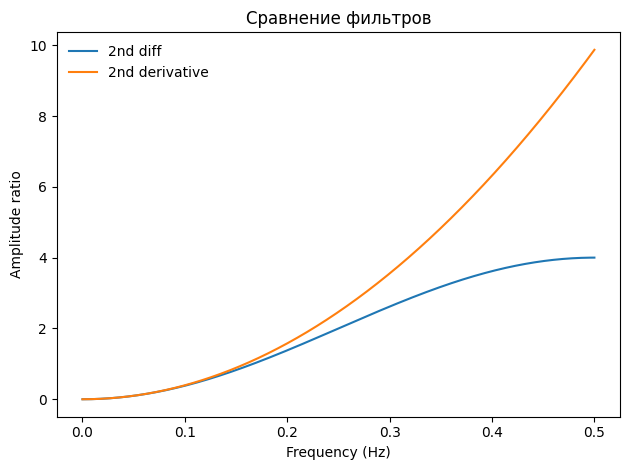

In [34]:
# Сравнение
diff2_filter.plot(label="2nd diff")
deriv2_filter.plot(label="2nd derivative")
decorate(xlabel="Frequency (Hz)", ylabel="Amplitude ratio", title="Сравнение фильтров")

**Вывод по 9.5.** После двух `diff` получается форма, похожая на пилообразный сигнал. После двух `differentiate` результат похож, но около точек негладкости возникает ringing. Оба фильтра являются фильтрами верхних частот, но они совпадают только на низких частотах. Вторая спектральная производная имеет амплитуду, пропорциональную $f^2$, а фильтр второй разности является лишь дискретной аппроксимацией этой зависимости и заметно расходится с ней около высоких частот.
